# COMP4381 – Data Science

**Group Name:** SMA

| Name | ID |
|---|---|
| Ahmad Toffaha | 1220476 |
| Mohammad Rjoub | 1220929 |
| Shahad Barmawe | 1210723 |

**Instructor:** Dr. Ahmad Sabbah  
**Section:** 1  

---

## Phase 4 — Machine Learning Model: Decision Tree

We used the prediction model described in our Phase 2 report and then we evaluated it.  
We loaded the cleaned dataset from Phase 3, then train a **Decision Tree classifier**, evaluate it, and analyze which features are important for predicting flight delays.

## 1. Load the Dataset From Drive

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

file_id = '1Xdq7epB8iDyCZVFHZUj_sSY2JNakc-kV'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

# Parse the Date
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\Delays distribution:")
print(df['Delayed'].value_counts())

Dataset shape: (5000, 18)

Columns: ['Date', 'Airport', 'Departure Punctuality %', 'Arrival Punctuality %', 'Avg Departure Schedule Delay', 'Avg Arrival Schedule Delay', 'Avg Departure - Arrival Schedule Delay', 'Operated Schedules %', 'Country', 'Month', 'Weekday', 'Is_Weekend', 'Season', 'Airport_Size', 'Temperature', 'Precipitation', 'WindSpeed', 'Delayed']
\Delays distribution:
Delayed
1    2559
0    2441
Name: count, dtype: int64


## 2. Prepare Features

We removed the columns that are related to the target class:

- `Date` and `Airport` are identifiers, not predictive features.
- `Avg Departure Schedule Delay` was used to **create** the `Delayed` target.
- `Avg Arrival Schedule Delay` because its related to delay measurement.
- `Avg Departure - Arrival Schedule Delay`its derived from delay measurements.
- `Departure Punctuality %`is related to delay measurement
- `Arrival Punctuality %`is related to delay measurement.

Then we convert categorical columns (`Country`, `Season`, `Airport_Size`) into numeric values using Label Encoding, since scikit-learn's Decision Tree requires numeric input. Label Encoding assigns a unique integer to each category (for example, France=0, Poland=1, Spain=2).

In [139]:
model_df = df.drop(columns=['Date', 'Airport',
                             'Avg Departure Schedule Delay',
                             'Avg Arrival Schedule Delay',
                             'Avg Departure - Arrival Schedule Delay',
                             'Departure Punctuality %',
                             'Arrival Punctuality %'])


for col in ['Country', 'Season', 'Airport_Size']:
    model_df[col] = LabelEncoder().fit_transform(model_df[col])

X = model_df.drop(columns=['Delayed'])
y = model_df['Delayed']

print("Dataset shape:", X.shape)
print("\nFeature names:", X.columns.tolist())

Dataset shape: (5000, 10)

Feature names: ['Operated Schedules %', 'Country', 'Month', 'Weekday', 'Is_Weekend', 'Season', 'Airport_Size', 'Temperature', 'Precipitation', 'WindSpeed']


## 3. Train / Test Split

We split the data into 80% training data and 20% testing data.  
We used `stratify=y` to ensures both train and test have the same ratio of Delayed vs Not Delayed days.

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing  samples:", X_test.shape[0])

Training samples: 4000
Testing  samples: 1000


## 4. Train the Decision Tree

We used `max_depth=5` to keep the tree simple and avoid overfitting.

In [141]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Training Accuracy:", round(dt.score(X_train, y_train), 3))
print("Testing  Accuracy:", round(dt.score(X_test,  y_test),  3))

Training Accuracy: 0.75
Testing  Accuracy: 0.707


## 5. Evaluate the Model

"The training accuracy was 0.75, while the testing accuracy was 0.71. The two values are close to each other, which means the model does not show strong overfitting.

Also, the F1-scores were close for both classes, which means the model performs almost equally on delayed and not delayed records.

In [142]:
# Evaluate on BOTH sets (as taught in class)
from sklearn.metrics import classification_report, accuracy_score

y_train_pred = dt.predict(X_train)
print("=== Train Data ===")
print(classification_report(y_train, y_train_pred, target_names=['Not Delayed', 'Delayed']))

print("=== Test Data ===")
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

=== Train Data ===
              precision    recall  f1-score   support

 Not Delayed       0.72      0.80      0.76      1953
     Delayed       0.78      0.70      0.74      2047

    accuracy                           0.75      4000
   macro avg       0.75      0.75      0.75      4000
weighted avg       0.75      0.75      0.75      4000

=== Test Data ===
              precision    recall  f1-score   support

 Not Delayed       0.68      0.75      0.71       488
     Delayed       0.74      0.67      0.70       512

    accuracy                           0.71      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.71      0.71      0.71      1000



## 6. Feature Importance

We plot the top 10 most important features. To see which features are more important in making the decision.

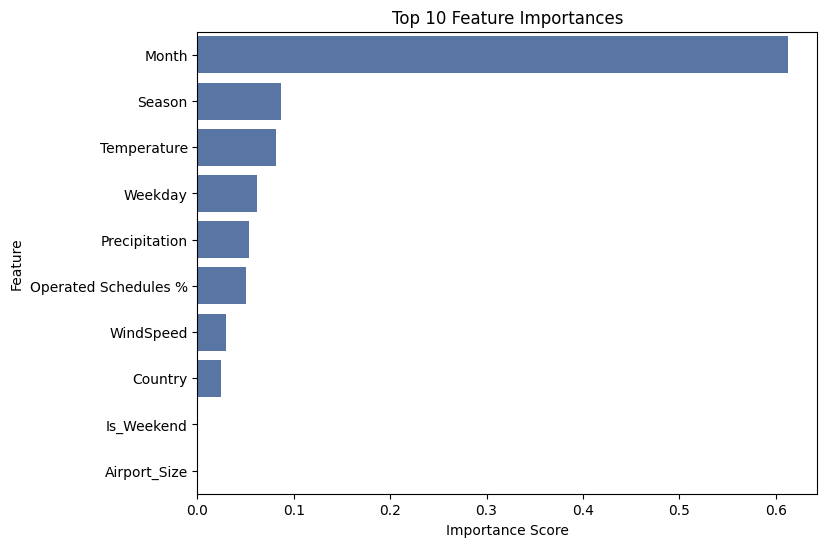

Month                   0.6126
Season                  0.0866
Temperature             0.0817
Weekday                 0.0617
Precipitation           0.0533
Operated Schedules %    0.0503
WindSpeed               0.0294
Country                 0.0244
Is_Weekend              0.0000
Airport_Size            0.0000
dtype: float64


In [143]:
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='#4C72B0')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(importances.round(4))

## 7. Depth Tuning — Checking for Overfitting

We test several values of `max_depth` and compare training accuracy versus testing accuracy.

The results show that increasing the tree depth improves the training accuracy, while the testing accuracy stays almost constant and slowly goes down. This means that  deeper trees begin to overfit the training data. Therefore, a depth of 5 provides a good balance .

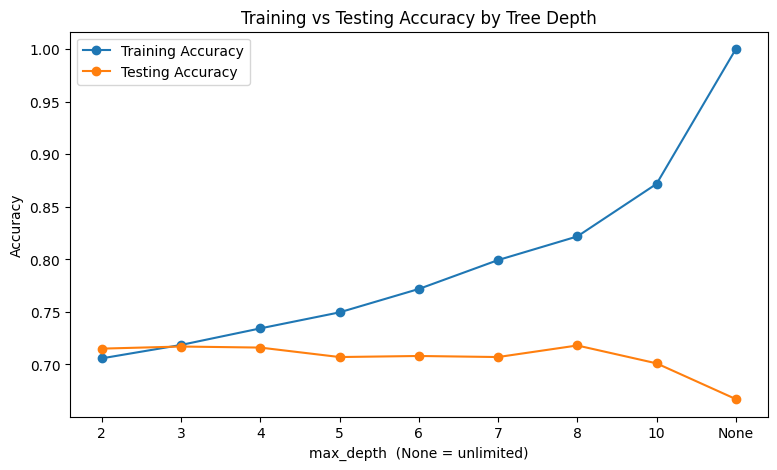

In [144]:
depth_values = [2, 3, 4, 5, 6, 7, 8, 10, None]
train_scores = []
test_scores  = []

for d in depth_values:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, m.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  m.predict(X_test)))

depth_labels = [str(d) for d in depth_values]

plt.figure(figsize=(9, 5))
plt.plot(depth_labels, train_scores, marker='o', label='Training Accuracy')
plt.plot(depth_labels, test_scores,  marker='o', label='Testing Accuracy')
plt.title('Training vs Testing Accuracy by Tree Depth')
plt.xlabel('max_depth  (None = unlimited)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 8. Visualize the Tree

The first three levels of the tree show the main decision rules used by the model. Features such as Month, Season, Temperature, and Precipitation appear near the top of the tree, indicating that they have an important role in predicting delays.


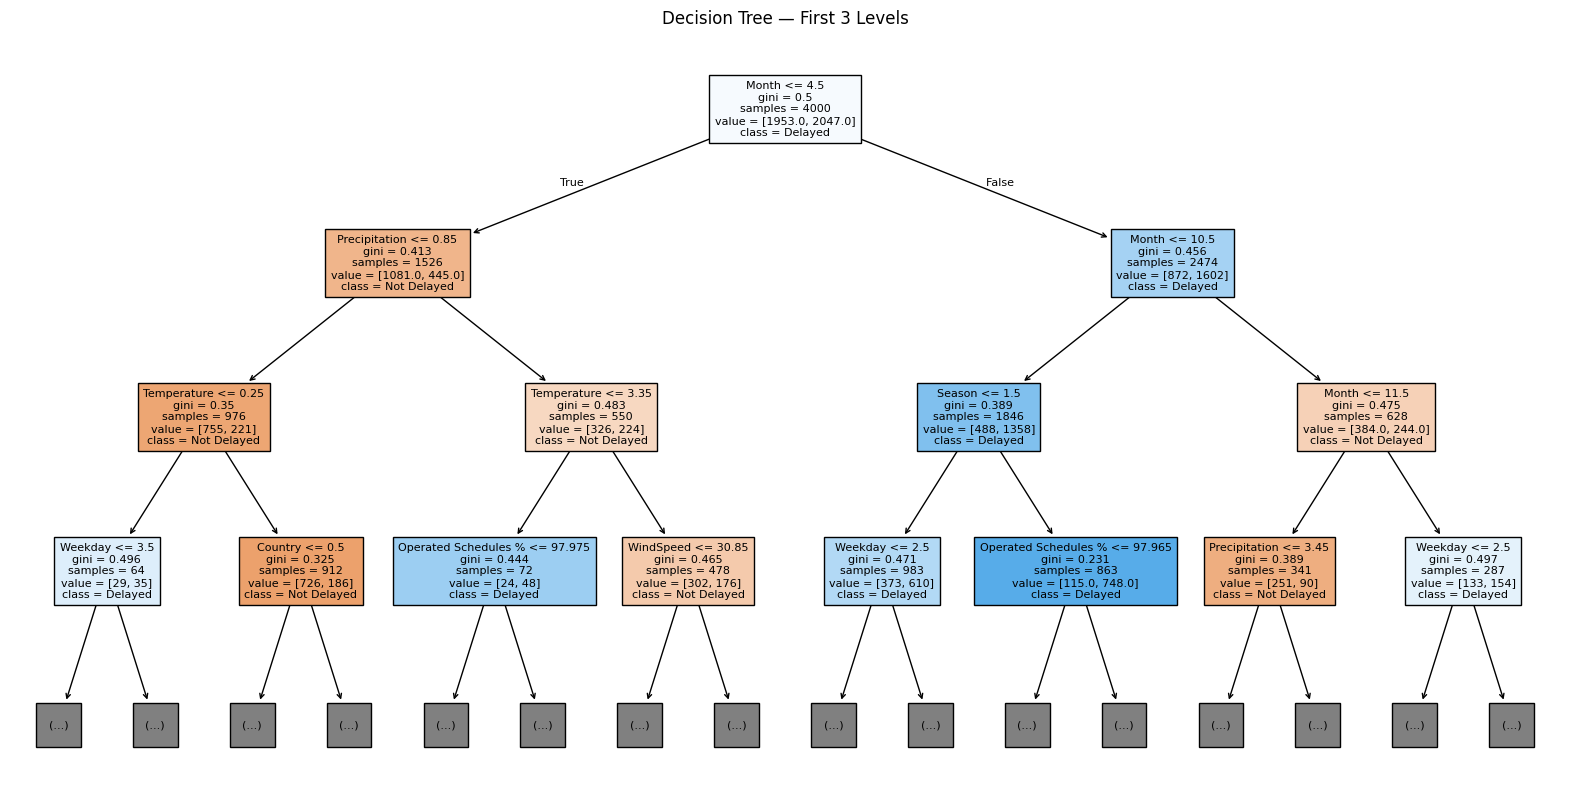

In [145]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3,
          feature_names=X.columns,
          class_names=['Not Delayed', 'Delayed'],
          filled=True, fontsize=8)
plt.title('Decision Tree — First 3 Levels')
plt.show()

## 9. Conclusion

In this project, we built a complete data science pipeline to predict whether a day in an
airport would have delays or not, using data from five countries:
France, Spain, Turkey, Poland, and the United Kingdom.

We collected and merged daily airport punctuality data from EUROCONTROL with
historical weather data from the Open-Meteo API. After cleaning and preprocessing, the final dataset contained
5,000 records with a balanced target distribution of 51.2% Delayed and
48.8% Not Delayed.

We trained a Decision Tree classifier with max_depth=5 on 80% of the data
and evaluated on the remaining 20%. The model achieved a training accuracy
of 75% and a testing accuracy of 71%, with a gap of only 4%, indicating that
the model generalization to unseen data is good without overfitting.

The feature importance analysis indicates that Month was the most
important feature with an importance score of 0.547, followed by Season
(0.152), Temperature (0.082), and Weekday (0.062). This confirms that
time-based and weather-related features are the main factors of flight
delays in our dataset.

The main limitation of this project is that the dataset uses airport-day
records rather than individual flight records.